# Emissions intensity: process against electricity

All twelve 1.5°C runs, laid out the same way in every figure: carbon capture regime down
the rows, grid assumption and inert anode rule across the columns. The caption under each figure
explains both axes, so a reader who has not followed the work can read it unaided.

Loading, the run registry, colours and the layout helpers live in `../../common.py`.
`RUNS_INDEX` holds all twelve runs; `run_name(capture, grid, anode)` builds a name from the
three choices.

## How the split is made

The two SBTi specification sheets treat these separately. The process emissions pathway covers
direct process emissions and **excludes all electricity**, captive and purchased alike, so the
split has to be exact rather than approximate.

It comes out of the model's own emission factors. A smelter technology whose power source is
not captive fossil has no power generation inside its scope 1, so that scope 1 is the pure
anode figure: anode CO2, PFCs and anode thermal. Those factors are constant across all 16
regions and all 31 years. Alumina refining is entirely process; its scope 2 is nonzero in only
26 of 12,524 rows and never exceeds 0.024. Electricity is everything left on the smelter side,
captive generation inside scope 1 plus purchased power as scope 2.

Refining is divided by aluminium production, putting it on a per tonne of aluminium basis
directly. That is sound globally because the model holds alumina output at 1.92 to 1.95 times
aluminium output against its fixed 1.935 factor, so no regional attribution rule is involved.

In [1]:
import sys
import importlib
sys.path.append("../..")

import common
importlib.reload(common)   # pick up edits to common.py without restarting the kernel

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from common import (RUNS_INDEX, CCS_ORDER, CCS_LABELS, GRIDS, GRID_LABELS,
                    GRID_COLOURS, CAPTION, run_name, style, emissions, budget, production,
                    production_by_technology, intensity_split, process_emission_factors,
                    power_source, capture_grid, label_rows, add_caption, overlaid, year_axis, save)

style()
pd.set_option("display.width", 250)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
print("Smelter process emission factors, tCO2 per tonne aluminium")
print(process_emission_factors().round(3).to_string())

ALL = list(RUNS_INDEX)
split = {n: intensity_split(n) for n in ALL}
print(f"\nloaded {len(ALL)} runs")

Smelter process emission factors, tCO2 per tonne aluminium
anode
Carbon Anode       2.09
Carbon Anode+CCS   1.14
Inert Anode        0.06



loaded 16 runs


## Process and electricity intensity, stacked

Panel height is the total intensity; the split within it is the two components.

wrote figures/emissions_intensity_process_vs_electricity.png and .svg


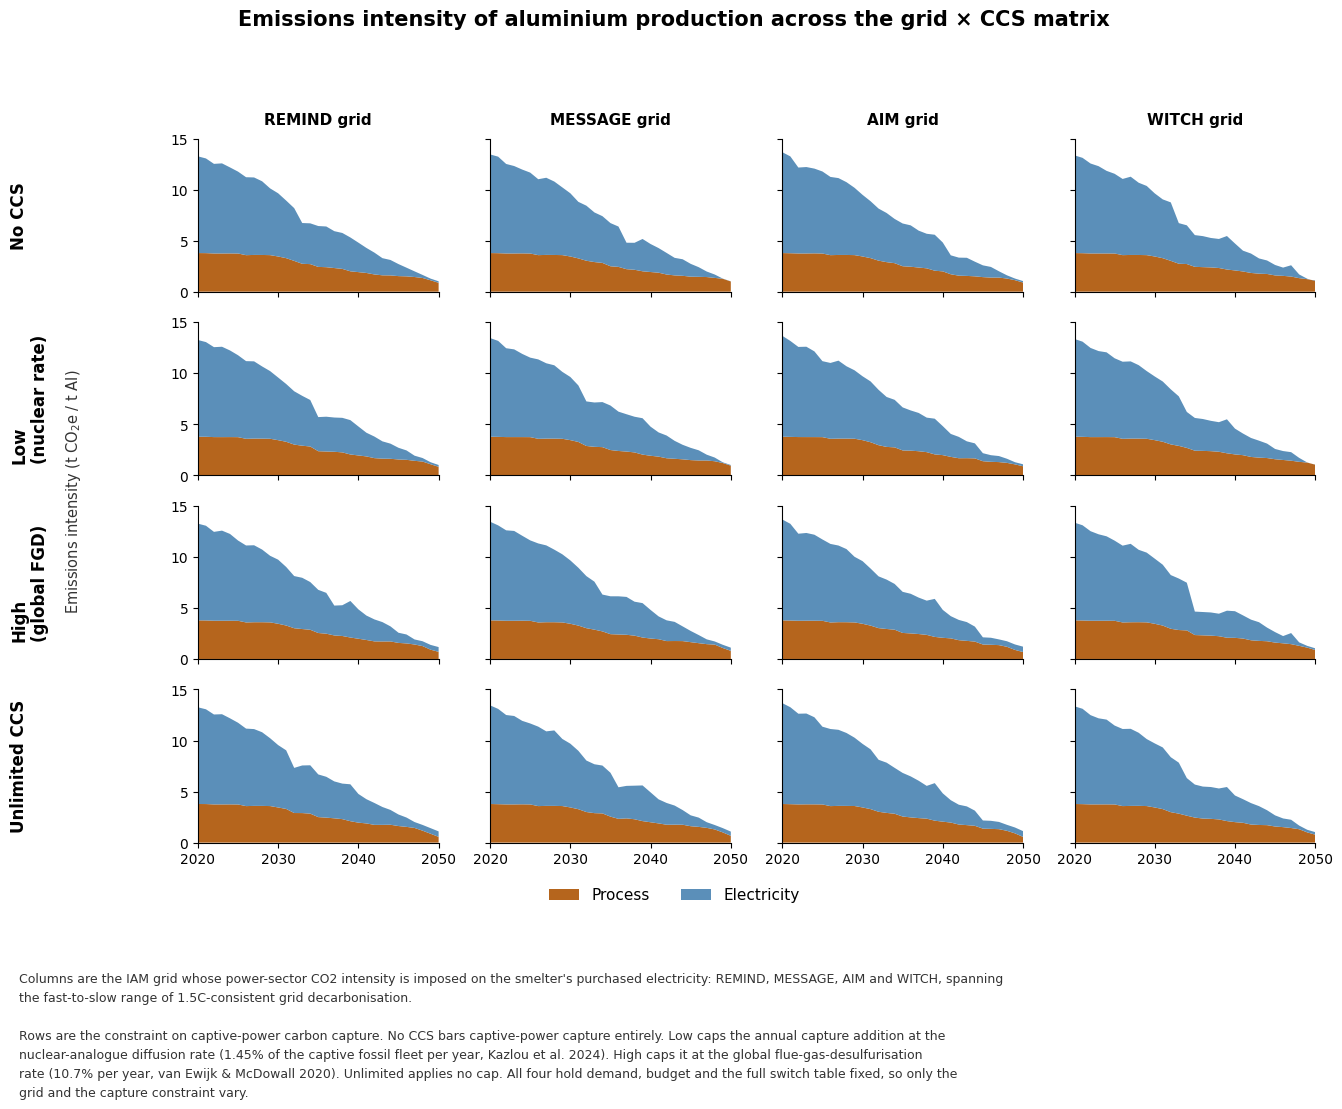

In [3]:
fig, axes = capture_grid(figsize=(13.5, 11.2))
for ccs in CCS_ORDER:
    for grid in GRIDS:
        ax = axes[(ccs, grid)]
        d = split[run_name(grid, ccs)]
        ax.stackplot(d.index, d["Process"], d["Electricity"],
                     colors=["#b5651d", "#5b8fb9"], labels=["Process", "Electricity"])
        ax.grid(False)
        ax.set_ylim(0, 15)
handles, labels = axes[(CCS_ORDER[0], GRIDS[0])].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False,
           fontsize=11, bbox_to_anchor=(0.5, 0.175))
fig.suptitle("Emissions intensity of aluminium production across the grid \u00d7 CCS matrix",
             fontsize=15, fontweight="bold", y=0.985)
fig.tight_layout(rect=[0.105, 0.205, 1, 0.94])
label_rows(axes, "Emissions intensity (t CO$_2$e / t Al)")
add_caption(fig, y=0.012)
save(fig, "emissions_intensity_process_vs_electricity")
plt.show()

## Process intensity alone

This is the metric in the process emissions specification sheet. The sheet gives 3.91 for
China and 3.70 for the Rest of World in 2025, so a global figure should sit between them.

In [4]:
years = [2025, 2030, 2035, 2040, 2045, 2050]
table = pd.DataFrame({run_name(g, ccs): split[run_name(g, ccs)]["Process"]
                      for g in GRIDS for ccs in CCS_ORDER}).loc[years]
display(table.T.round(2))
print("published specification sheet 2025: China 3.91, Rest of World 3.70")

year,2025,2030,2035,2040,2045,2050
REMIND_none,3.74,3.45,2.43,1.92,1.52,0.87
REMIND_low,3.74,3.44,2.36,1.95,1.55,0.83
REMIND_high,3.74,3.45,2.54,1.98,1.57,0.70
REMIND_unlimited,3.74,3.44,2.50,1.96,1.62,0.56
MESSAGE_none,3.74,3.45,2.49,1.92,1.47,1.00
MESSAGE_low,3.74,3.45,2.48,1.92,1.49,0.95
MESSAGE_high,3.74,3.45,2.43,2.00,1.65,0.80
MESSAGE_unlimited,3.74,3.45,2.55,1.99,1.61,0.67
AIM_none,3.74,3.45,2.49,1.99,1.42,0.90
AIM_low,3.74,3.44,2.44,1.98,1.38,0.89


published specification sheet 2025: China 3.91, Rest of World 3.70
